setting up

In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import plotly.express as px 
from matplotlib import pyplot as plt
from sklearn.model_selection import cross_val_score

from collections import Counter

In [4]:
raw_df = pd.read_csv('heart.csv')

In [5]:
raw_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2.4 Dataset Attributes

- **Age**: Age of the patient *(years)*.

- **Sex**: Sex of the patient.
  - **M**: Male
  - **F**: Female

- **ChestPainType**: Type of chest pain.
  - **TA**: Typical Angina
  - **ATA**: Atypical Angina
  - **NAP**: Non-Anginal Pain
  - **ASY**: Asymptomatic

- **RestingBP**: Resting blood pressure *(mm Hg)*.

- **Cholesterol**: Serum cholesterol *(mm/dl)*.

- **FastingBS**: Fasting blood sugar.
  - **1**: FastingBS > 120 mg/dl
  - **0**: Otherwise

- **RestingECG**: Resting electrocardiogram results.
  - **Normal**: Normal ECG
  - **ST**: ST-T wave abnormality *(T-wave inversions and/or ST elevation or depression > 0.05 mV)*
  - **LVH**: Probable or definite left ventricular hypertrophy *(Estes' criteria)*

- **MaxHR**: Maximum heart rate achieved *(numeric value between 60 and 202)*.

- **ExerciseAngina**: Exercise-induced angina.
  - **Y**: Yes
  - **N**: No

- **Oldpeak**: ST depression induced by exercise relative to rest *(numeric value measured in depression)*.

- **ST_Slope**: Slope of the peak exercise ST segment.
  - **Up**: Upsloping
  - **Flat**: Flat
  - **Down**: Downsloping

- **HeartDisease**: Target (output) class.
  - **1**: Heart disease
  - **0**: Normal

## 3. Data Pre-processing

In [7]:
raw_df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

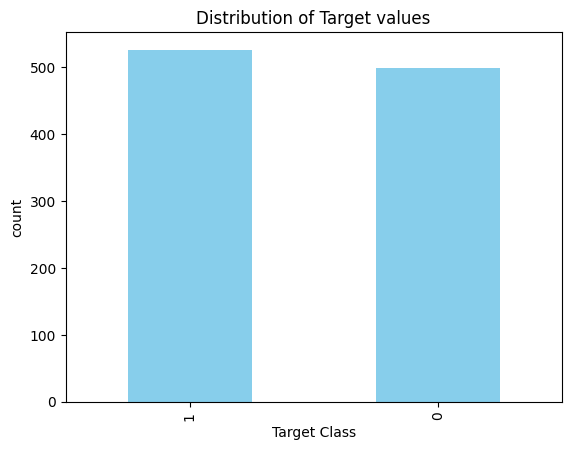

In [8]:
raw_df['target'].value_counts().plot(kind='bar',color='skyblue')

plt.title('Distribution of Target values')
plt.xlabel('Target Class')
plt.ylabel('count')
plt.show()

Checking for outliers

In [9]:
raw_df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


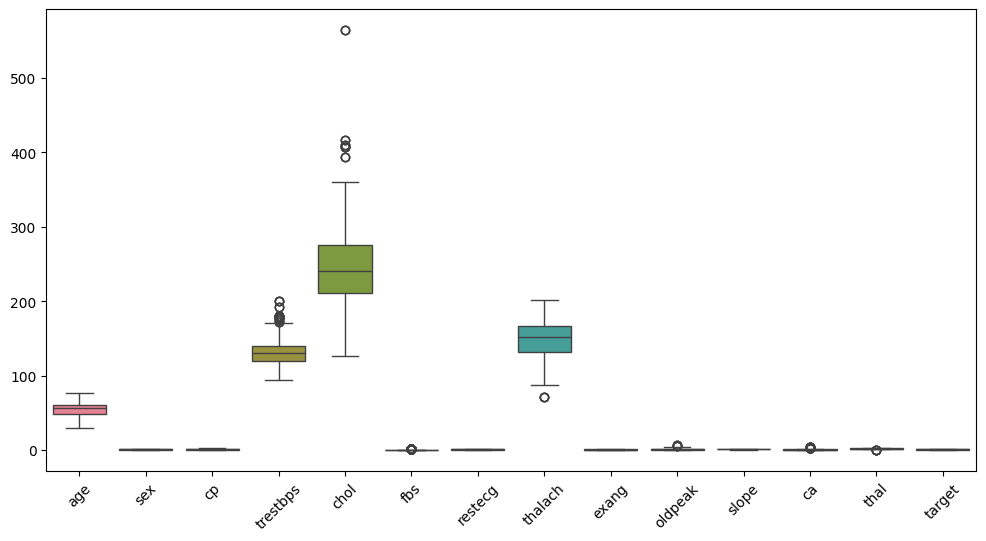

In [10]:
import seaborn as sns

#box plot for single numemerical column
plt.figure(figsize=(12,6))
sns.boxplot(data=raw_df.select_dtypes(include='number'))
plt.xticks(rotation =45)
plt.show()

removing outliers with the use of a function


In [13]:
import pandas as pd

def remove_outliers_iqr(df, columns=None, factor=2, verbose=True):
    """
    Detects and removes outliers from a DataFrame using the IQR method.
    
    Parameters:
    ----------
    df : pandas.DataFrame
        The input DataFrame.
    columns : list, optional
        List of column names to evaluate for outliers. 
        If None, automatically selects all numeric columns.
    factor : float, default 1.5
        The IQR multiplier (1.5 is standard, 3.0 for extreme outliers).
    verbose : bool, default True
        If True, prints details about rows removed.
        
    Returns:
    -------
    pandas.DataFrame
        DataFrame with outliers removed.
    """
    df_cleaned = df.copy()
    initial_shape = df_cleaned.shape[0]
    
    # If no columns specified, select all numerical columns
    if columns is None:
        columns = df_cleaned.select_dtypes(include=['number']).columns.tolist()
    
    # Track rows to keep
    condition = pd.Series(True, index=df_cleaned.index)
    
    for col in columns:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - (factor * IQR)
        upper_bound = Q3 + (factor * IQR)
        
        # Combine condition for rows within bounds
        col_condition = (df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)
        
        if verbose:
            outliers_count = (~col_condition).sum()
            print(f"Column '{col}': found {outliers_count} outliers (bounds: [{lower_bound:.2f}, {upper_bound:.2f}])")
            
        condition = condition & col_condition
        
    df_cleaned = df_cleaned[condition]
    final_shape = df_cleaned.shape[0]
    
    if verbose:
        removed_rows = initial_shape - final_shape
        print("-" * 50)
        print(f"Total rows before: {initial_shape}")
        print(f"Total rows after:  {final_shape}")
        print(f"Removed {removed_rows} row(s) ({(removed_rows / initial_shape) * 100:.2f}%)")
        print("-" * 50)
        
    return df_cleaned


In [14]:
# Select feature columns (excluding target variable)
feature_cols = [col for col in raw_df.columns if col != 'target']
# Clean dataframe
cleaned_df = remove_outliers_iqr(raw_df, columns=feature_cols)

Column 'age': found 0 outliers (bounds: [22.00, 87.00])
Column 'sex': found 0 outliers (bounds: [-2.00, 3.00])
Column 'cp': found 0 outliers (bounds: [-4.00, 6.00])
Column 'trestbps': found 7 outliers (bounds: [80.00, 180.00])
Column 'chol': found 13 outliers (bounds: [83.00, 403.00])
Column 'fbs': found 153 outliers (bounds: [0.00, 0.00])
Column 'restecg': found 0 outliers (bounds: [-2.00, 3.00])
Column 'thalach': found 0 outliers (bounds: [64.00, 234.00])
Column 'exang': found 0 outliers (bounds: [-2.00, 3.00])
Column 'oldpeak': found 7 outliers (bounds: [-3.60, 5.40])
Column 'slope': found 0 outliers (bounds: [-1.00, 4.00])
Column 'ca': found 18 outliers (bounds: [-2.00, 3.00])
Column 'thal': found 0 outliers (bounds: [0.00, 5.00])
--------------------------------------------------
Total rows before: 1025
Total rows after:  837
Removed 188 row(s) (18.34%)
--------------------------------------------------


In [15]:
cleaned_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0


In [16]:
X = cleaned_df.drop('target', axis=1)
y = cleaned_df['target']

Train test split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test,y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

ct = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough', # Keeps sex, cp, fbs, restecg, exang, slope, ca, thal intact
    verbose_feature_names_out=False
)

# 1. FIT and TRANSFORM on X_train
X_train_scaled = ct.fit_transform(X_train)

# 2. ONLY TRANSFORM on X_test
X_test_scaled = ct.transform(X_test)


Model selection

In [21]:
from sklearn.ensemble import  VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [20]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, classification_report

In [23]:
estimator = []
estimator.append(('Neural Network', MLPClassifier(max_iter = 10000) ))
estimator.append(('LogisticRegression', LogisticRegression(solver ='lbfgs', max_iter = 200)))
estimator.append(('ExtraTreesClassifier', ExtraTreesClassifier() ))
estimator.append(('RandomForest', RandomForestClassifier() ))
#estimator.append(('KNN', KNeighborsClassifier() ))
estimator.append(('SVC', SVC(gamma ='auto', probability = True)))
estimator.append(('AdaBoostClassifier', AdaBoostClassifier() ))
estimator.append(('GradientBoostingClassifier', GradientBoostingClassifier() ))
estimator.append(('XGB', XGBClassifier() ))
estimator.append(('CatBoost', CatBoostClassifier(logging_level='Silent') ))

Voting Classifier with hard voting

In [44]:
vc_hard = VotingClassifier(estimators=estimator, voting='hard')

vc_hard.fit(X_train_scaled,y_train)
y_pred = vc_hard.predict(X_test_scaled)

Classification report

In [45]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        86
           1       1.00      0.96      0.98        82

    accuracy                           0.98       168
   macro avg       0.98      0.98      0.98       168
weighted avg       0.98      0.98      0.98       168



Confusion matrix

In [46]:
print(confusion_matrix(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(f1_score(y_test,y_pred))
print('accuracy is',accuracy_score(y_test,y_pred))


[[86  0]
 [ 3 79]]
0.9634146341463414
1.0
0.9813664596273292
accuracy is 0.9821428571428571


## K-Fold Cross-validation
Cross-validation is a resampling procedure used to evaluate machine learning models on a limited data sample. The procedure has a single parameter called k that refers to the number of groups that a given data sample is to be split into. As such, the procedure is often called k-fold cross-validation.

The purpose of cross–validation is to test the ability of a machine learning model to predict new data.

In [47]:
from statistics import  stdev

score = cross_val_score(vc_hard, X_train_scaled,y_train,cv=5, scoring='recall')

VC_hard_cv_score= score.mean()
VC_hard_cv_stdev = stdev(score)
print('Cross Validation Recall scores are: {}'.format(score))
print('Average Cross Validation Recall score: ', VC_hard_cv_score)
print('Cross Validation Recall standard deviation: ', VC_hard_cv_stdev)

Cross Validation Recall scores are: [0.95774648 1.         1.         0.98591549 0.97183099]
Average Cross Validation Recall score:  0.9830985915492958
Cross Validation Recall standard deviation:  0.018363950437190572


Voting classifier with soft voting

In [48]:
VC_soft = VotingClassifier(estimators = estimator, voting ='soft')
VC_soft.fit(X_train_scaled, y_train)
y_pred = VC_soft.predict(X_test_scaled)

classification report

In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        86
           1       1.00      0.96      0.98        82

    accuracy                           0.98       168
   macro avg       0.98      0.98      0.98       168
weighted avg       0.98      0.98      0.98       168



Confusion Matrix

In [50]:
print(confusion_matrix(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(f1_score(y_test,y_pred))
print('accuracy is',accuracy_score(y_test,y_pred))


[[86  0]
 [ 3 79]]
0.9634146341463414
1.0
0.9813664596273292
accuracy is 0.9821428571428571


K-Fold Cross-validation on soft

In [51]:
score2 = cross_val_score(VC_soft, X_train_scaled, y_train, cv=5, scoring='recall')

In [52]:
VC_soft_cv_score = score2.mean()
VC_soft_cv_stdev = stdev(score2)

print('Soft Voting result')
print('Cross Validation Recall scores are: {}'.format(score2))
print('Average Cross Validation Recall score: ', VC_soft_cv_score)
print('Cross Validation Recall standard deviation: ', VC_soft_cv_stdev)

Soft Voting result
Cross Validation Recall scores are: [0.95774648 1.         1.         1.         0.97183099]
Average Cross Validation Recall score:  0.9859154929577464
Cross Validation Recall standard deviation:  0.01991850087849431
